In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import tensorflow as tf
import time
import tensorflow as tf
import tensorflow.python.keras
import matplotlib.pyplot as plt


In [2]:
from tensorflow.keras.applications.inception_v3 import InceptionV3 # InceptionV3
from tensorflow import keras
from tensorflow.keras.layers import Flatten, Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import plot_model
from glob import glob

In [3]:
IMAGE_SIZE = [224,224]

In [4]:
# Create InceptionV3 Layer
inception = InceptionV3(include_top=False,weights='imagenet',input_shape=IMAGE_SIZE + [3])
for layer in inception.layers:
  layer.trainable = False

In [5]:
# we will use the glob to see how many outputs / labels there are
folders = glob('./plantvillage/*')

In [6]:
folders

['./plantvillage\\Tomato___Bacterial_spot',
 './plantvillage\\Tomato___Early_blight',
 './plantvillage\\Tomato___healthy',
 './plantvillage\\Tomato___Late_blight',
 './plantvillage\\Tomato___Leaf_Mold',
 './plantvillage\\Tomato___Septoria_leaf_spot',
 './plantvillage\\Tomato___Spider_mites Two-spotted_spider_mite',
 './plantvillage\\Tomato___Target_Spot',
 './plantvillage\\Tomato___Tomato_mosaic_virus',
 './plantvillage\\Tomato___Tomato_Yellow_Leaf_Curl_Virus']

In [7]:
# Add Flatten and Dense in last layers
x = GlobalAveragePooling2D()(inception.output)
x = Dropout(0.5)(x)
prediction = Dense(len(folders),activation='softmax')(x)

In [8]:
model = Model(inputs=inception.input,outputs = prediction)
plot_model(model)

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.


In [9]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 111, 111,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 111, 111,  │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 111, 111,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 109, 109,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │         96 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 109, 109,  │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 54, 54,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 54, 54,    │      5,120 │ max_pooling2d[0]… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 54, 54,    │        240 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 54, 54,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 52, 52,    │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 52, 52,    │        576 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 52, 52,    │          0 │ batch_normalizat

 Total params: 21,823,274 (83.25 MB)

 Trainable params: 20,490 (80.04 KB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [10]:
# Compile the model that we have created with adam and the loss is categorical_crossentropy because the classification is more than 2 classes
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [ ]:
# Then use the CustomImageDataGenerator instead of ImageDataGenerator
train_datagen = ImageDataGenerator(
    validation_split=0.2,
    rescale=1./255,
    rotation_range=10,           # Very small rotations
    width_shift_range=0.05,      # Minimal shifts
    height_shift_range=0.05,
    shear_range=0.05,
    zoom_range=0.1,              # Small zoom
    horizontal_flip=True,
    fill_mode='nearest'
)


val_datagen = ImageDataGenerator(validation_split=0.2, rescale=1./255)
test_datagen = ImageDataGenerator(validation_split=0.2, rescale=1./255)

In [ ]:
# Load training and validation data using tf.data.Dataset
training_set = train_datagen.flow_from_directory(
    './plantvillage/',
    target_size=(224, 224),
    batch_size=8,
    class_mode='categorical',  # Make sure this is set to categorical
    subset='training',
    shuffle = True
)

val_set = val_datagen.flow_from_directory(
    './plantvillage/',
    target_size=(224, 224),
    batch_size=8,
    class_mode='categorical',  # Make sure this is set to categorical
    subset='validation'
)

test_dataset = test_datagen.flow_from_directory(
    './plantvillage/', 
    target_size=(224, 224),
    batch_size = 8,
    class_mode = 'categorical',
    shuffle = False

)


Found 10288 images belonging to 10 classes.
Found 2567 images belonging to 10 classes.
Found 12855 images belonging to 10 classes.


In [13]:
print(training_set)
print(val_set)

In [14]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)

In [15]:
tic = time.perf_counter()
history = model.fit(training_set,
                    steps_per_epoch=len(training_set),
                    validation_data=val_set,
                    validation_steps=len(val_set),
                    epochs=20, callbacks=[early_stopping, reduce_lr])
# time
toc = time.perf_counter()
model.save('Inception_V3test.keras')


c:\Users\glmun\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
1286/1286 ━━━━━━━━━━━━━━━━━━━━ 0s 536ms/step - accuracy: 0.5692 - loss: 1.3409

c:\Users\glmun\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1286/1286 ━━━━━━━━━━━━━━━━━━━━ 840s 641ms/step - accuracy: 0.5692 - loss: 1.3407 - val_accuracy: 0.7998 - val_loss: 0.6012 - learning_rate: 0.0010
Epoch 2/20
1286/1286 ━━━━━━━━━━━━━━━━━━━━ 688s 535ms/step - accuracy: 0.7532 - loss: 0.7434 - val_accuracy: 0.8037 - val_loss: 0.5865 - learning_rate: 0.0010
Epoch 3/20
1286/1286 ━━━━━━━━━━━━━━━━━━━━ 688s 535ms/step - accuracy: 0.7635 - loss: 0.7347 - val_accuracy: 0.8095 - val_loss: 0.5444 - learning_rate: 0.0010
Epoch 4/20
1286/1286 ━━━━━━━━━━━━━━━━━━━━ 681s 529ms/step - accuracy: 0.7806 - loss: 0.6894 - val_accuracy: 0.8165 - val_loss: 0.5870 - learning_rate: 0.0010
Epoch 5/20
 745/1286 ━━━━━━━━━━━━━━━━━━━━ 4:28 496ms/step - accuracy: 0.7809 - loss: 0.6858

KeyboardInterrupt: 

In [ ]:
print("Total Time:{}".format(round((toc-tic)/60,2)))

Total Time:233.37


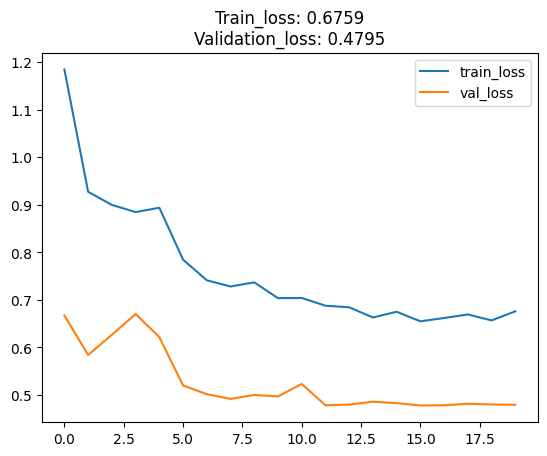

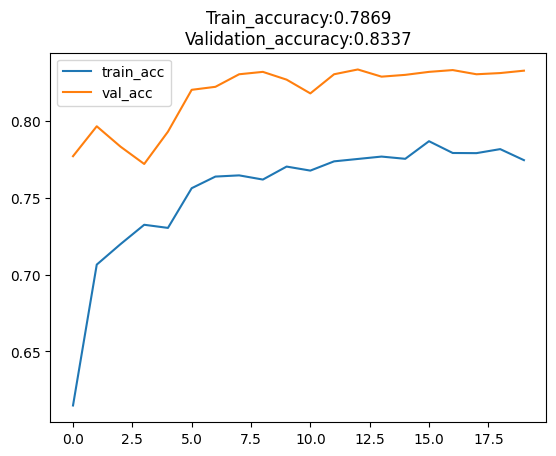

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.plot(loss, label='train_loss')
plt.plot(val_loss,label = 'val_loss')
plt.legend()
plt.title("Train_loss: {:.4f}".format(history.history['loss'][-1]) +
          "\nValidation_loss: {:.4f}".format(history.history['val_loss'][-1]))
plt.savefig('inceptionv3_loss.png', dpi=150, bbox_inches='tight')
plt.show()

plt.plot(acc, label='train_acc')
plt.plot(val_acc,label = 'val_acc')
plt.title("Train_accuracy:{:.4f}".format(max(history.history['accuracy']))+
         "\nValidation_accuracy:{:.4f}".format(max(history.history['val_accuracy'])))
plt.legend()
plt.savefig('inceptionv3_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
scores = model.evaluate(test_dataset)

1607/1607 ━━━━━━━━━━━━━━━━━━━━ 598s 372ms/step - accuracy: 0.7686 - loss: 0.6699


In [ ]:
y_pred = model.predict(test_dataset)    

1607/1607 ━━━━━━━━━━━━━━━━━━━━ 599s 371ms/step


In [ ]:
y_predict = np.argmax(y_pred,axis=1)
y_predict

array([4, 4, 2, ..., 9, 9, 9], dtype=int64)

In [ ]:
y_true = test_dataset.classes
y_true

array([0, 0, 0, ..., 9, 9, 9])

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
class_name = ['Tomato_Bacterial_spot','Tomato_Early_blight','Tomato_Late_blight','Tomato_Leaf_Mold','Tomato_Septoria_leaf_spot','Tomato_Spider_mites_Two_spotted_spider_mite','Tomato__Target_Spot','Tomato__Tomato_YellowLeaf__Curl_Virus','Tomato__Tomato_mosaic_virus','Tomato_healthy']

In [ ]:
print(classification_report(y_true,y_predict,target_names = class_name))

                                             precision    recall  f1-score   support

                      Tomato_Bacterial_spot       0.50      0.07      0.12        28
                        Tomato_Early_blight       0.75      0.60      0.67       800
                         Tomato_Late_blight       0.79      0.88      0.83      1527
                           Tomato_Leaf_Mold       0.85      0.66      0.74       761
                  Tomato_Septoria_leaf_spot       0.73      0.84      0.78      1417
Tomato_Spider_mites_Two_spotted_spider_mite       0.79      0.80      0.79      1341
                        Tomato__Target_Spot       0.76      0.67      0.71      1123
      Tomato__Tomato_YellowLeaf__Curl_Virus       0.97      0.97      0.97      4286
                Tomato__Tomato_mosaic_virus       0.81      0.61      0.70       299
                             Tomato_healthy       0.83      0.92      0.87      1273

                                   accuracy                    

In [ ]:
import seaborn as sns

In [ ]:
cm = confusion_matrix(y_true,y_predict)
cm

array([[   2,    1,    3,    0,   13,    1,    3,    2,    0,    3],
       [   1,  481,   91,   10,  103,   41,   40,   11,    3,   19],
       [   0,   63, 1346,   21,   24,   15,   28,    3,    0,   27],
       [   0,   21,   66,  505,   89,   29,    8,   22,   14,    7],
       [   0,   39,   69,   19, 1188,   16,   44,   22,    5,   15],
       [   0,    2,   34,   12,   44, 1069,   60,   39,   12,   69],
       [   1,   20,   45,    3,   74,  101,  753,   21,    5,  100],
       [   0,   13,   12,    8,   56,   44,    5, 4141,    2,    5],
       [   0,    4,   29,   18,   35,   12,    0,   17,  182,    2],
       [   0,    1,   11,    0,    8,   32,   46,    1,    1, 1173]],
      dtype=int64)

In [ ]:
cm_normalized = np.round(cm/np.sum(cm,axis=1).reshape(-1,1),2)
print(cm_normalized)

[[0.07 0.04 0.11 0.   0.46 0.04 0.11 0.07 0.   0.11]
 [0.   0.6  0.11 0.01 0.13 0.05 0.05 0.01 0.   0.02]
 [0.   0.04 0.88 0.01 0.02 0.01 0.02 0.   0.   0.02]
 [0.   0.03 0.09 0.66 0.12 0.04 0.01 0.03 0.02 0.01]
 [0.   0.03 0.05 0.01 0.84 0.01 0.03 0.02 0.   0.01]
 [0.   0.   0.03 0.01 0.03 0.8  0.04 0.03 0.01 0.05]
 [0.   0.02 0.04 0.   0.07 0.09 0.67 0.02 0.   0.09]
 [0.   0.   0.   0.   0.01 0.01 0.   0.97 0.   0.  ]
 [0.   0.01 0.1  0.06 0.12 0.04 0.   0.06 0.61 0.01]
 [0.   0.   0.01 0.   0.01 0.03 0.04 0.   0.   0.92]]


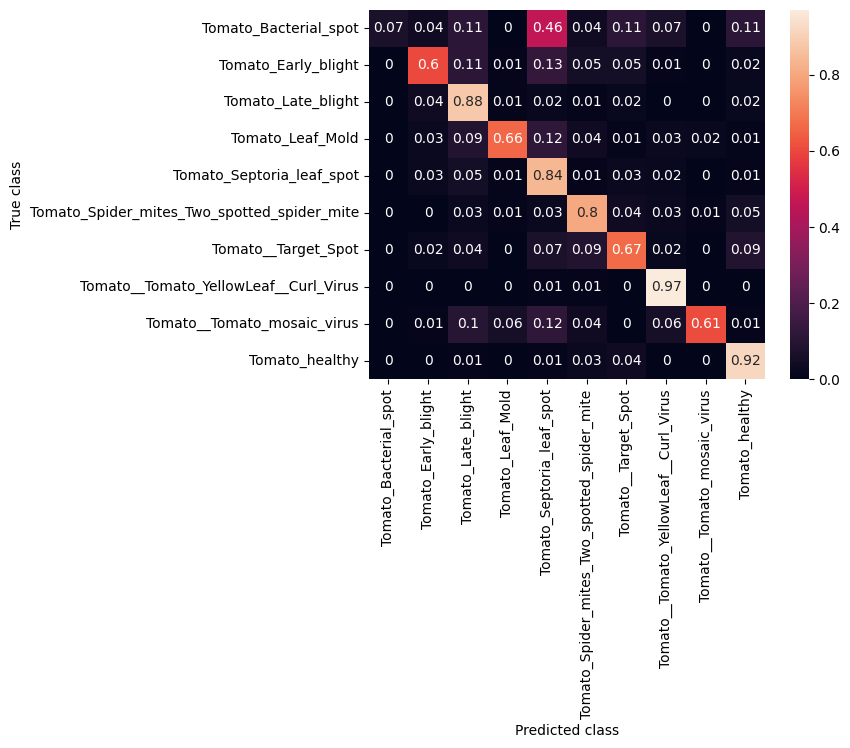

In [ ]:
sns.heatmap(cm_normalized, annot=True,xticklabels=class_name, yticklabels=class_name,)
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.savefig('inceptionv3_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

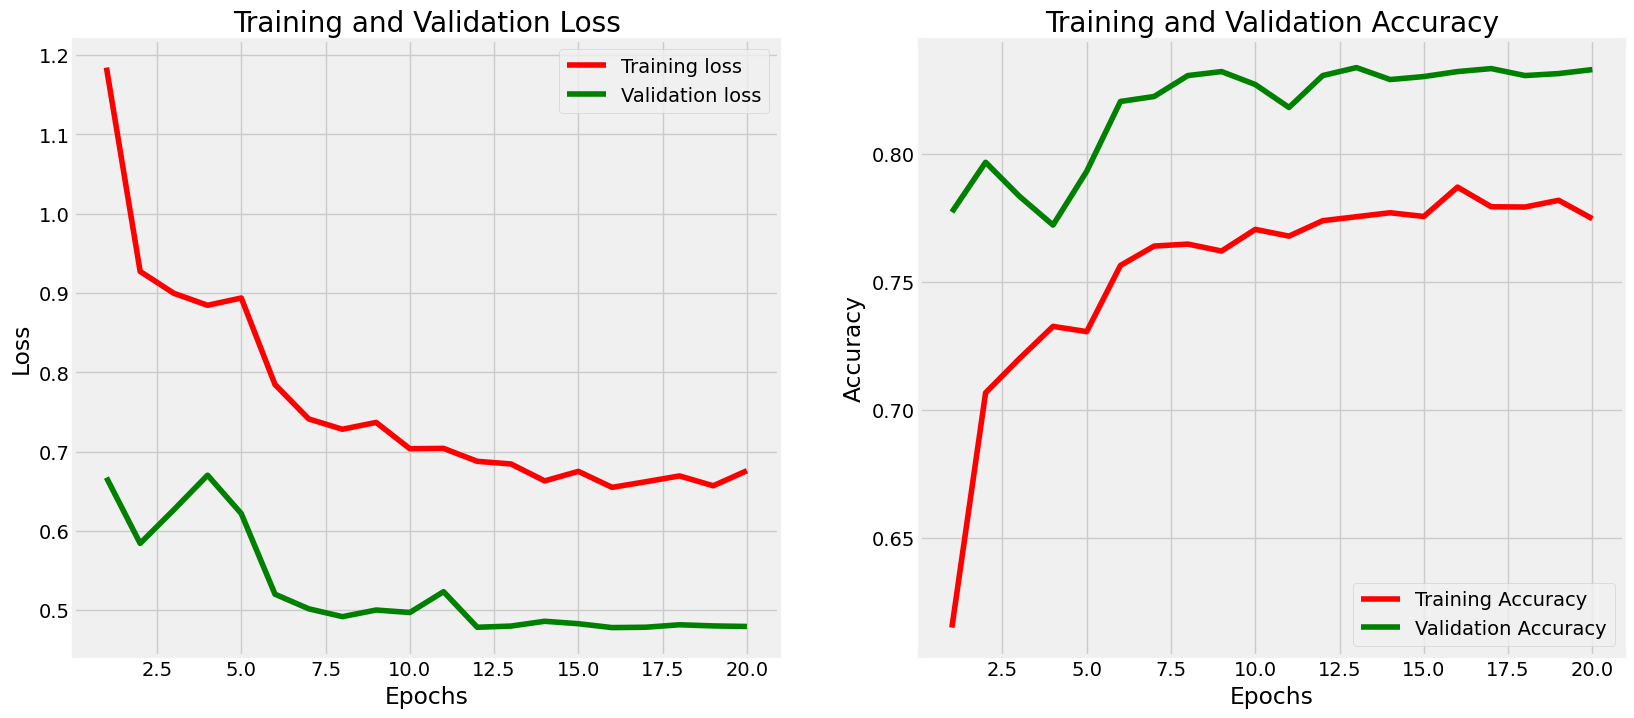

In [ ]:
tr_acc = history.history['accuracy']
tr_loss = history.history['loss']
val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']

Epochs = [i+1 for i in range(len(tr_acc))]

plt.figure(figsize= (20, 8))
plt.style.use('fivethirtyeight')

plt.subplot(1, 2, 1)
plt.plot(Epochs, tr_loss, 'r', label= 'Training loss')
plt.plot(Epochs, val_loss, 'g', label= 'Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(Epochs, tr_acc, 'r', label= 'Training Accuracy')
plt.plot(Epochs, val_acc, 'g', label= 'Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout
plt.show()

In [ ]:
import pickle
# Save the history object to a file
with open('history_inceptionv3.pkl', 'wb') as file:
    pickle.dump(history.history, file)